# Modelo predictivo Fintech — Regresión Logística

Este notebook reorganiza el modelo de clasificación para que el flujo sea claro, reproducible y fácilmente desplegable.

## Flujo

1. Configuración e importación de librerías.
2. Carga del dataset procesado.
3. Selección de variables.
4. Separación entrenamiento / validación / test.
5. Preprocesamiento.
6. Entrenamiento de una regresión logística.
7. Evaluación con threshold estándar.
8. Selección del threshold usando **validación**, no test.
9. Evaluación final sobre test.
10. Interpretación del modelo.
11. Entrenamiento del pipeline final.
12. Guardado del modelo y metadatos para producción.

> El conjunto de **test no se utiliza para elegir el threshold**. Se reserva para la evaluación final del modelo.


## Paso 1. Importación de librerías y configuración


In [1]:
# Importamos Path para construir rutas de forma segura y reproducible.
from pathlib import Path
# Importamos json para guardar los metadatos del modelo.
import json
# Importamos joblib para serializar el pipeline entrenado.
import joblib
# Importamos numpy para realizar operaciones numéricas.
import numpy as np
# Importamos pandas para manipular los datos.
import pandas as pd
# Importamos seaborn para crear visualizaciones estadísticas.
import seaborn as sns
# Importamos matplotlib para representar los resultados del modelo.
import matplotlib.pyplot as plt

# Importamos train_test_split para separar entrenamiento, validación y test.
from sklearn.model_selection import train_test_split
# Importamos ColumnTransformer para aplicar transformaciones distintas según el tipo de variable.
from sklearn.compose import ColumnTransformer
# Importamos Pipeline para encapsular preprocesamiento y modelo en un único objeto.
from sklearn.pipeline import Pipeline
# Importamos OneHotEncoder para codificar variables categóricas.
from sklearn.preprocessing import OneHotEncoder
# Importamos StandardScaler para estandarizar las variables numéricas.
from sklearn.preprocessing import StandardScaler
# Importamos LogisticRegression para construir el modelo de clasificación.
from sklearn.linear_model import LogisticRegression
# Importamos las métricas utilizadas para evaluar el modelo.
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Importamos ROC-AUC y la curva ROC para evaluar la capacidad discriminativa.
from sklearn.metrics import roc_auc_score, roc_curve
# Importamos precision, recall y F1 para estudiar distintos thresholds.
from sklearn.metrics import precision_score, recall_score, f1_score

# Definimos una semilla común para garantizar reproducibilidad.
RANDOM_STATE = 42
# Configuramos pandas para mostrar todas las columnas.
pd.set_option("display.max_columns", None)
# Aplicamos un estilo visual homogéneo a los gráficos.
sns.set_theme(style="whitegrid")


## Paso 2. Definición de rutas del proyecto


In [3]:
# Definimos la carpeta raíz del proyecto Fintech.
PROJECT_DIR = Path("/home/diego/Escritorio/Fintech_TFM")
# Definimos la carpeta donde se encuentra el dataset procesado.
PROCESSED_DIR = PROJECT_DIR / "00_data" / "01_processed"
# Definimos la ruta exacta del dataset limpio generado por el notebook de EDA.
DATA_FILE = PROCESSED_DIR / "df_fintech_final.csv"
# Definimos una carpeta específica para guardar los artefactos del modelo.
MODEL_DIR = PROJECT_DIR / "03_models"
# Creamos la carpeta de modelos si todavía no existe.
MODEL_DIR.mkdir(parents=True, exist_ok=True)
# Definimos la ruta del pipeline final serializado.
MODEL_FILE = MODEL_DIR / "logistic_regression_pipeline.joblib"
# Definimos la ruta del fichero de metadatos.
METADATA_FILE = MODEL_DIR / "logistic_regression_metadata.json"

# Comprobamos que el dataset procesado existe antes de continuar.
assert DATA_FILE.exists(), f"No se encuentra el dataset procesado: {DATA_FILE}"
# Mostramos la ruta de entrada.
print(f"Dataset: {DATA_FILE}")
# Mostramos la ruta en la que se guardará el modelo.
print(f"Modelo: {MODEL_FILE}")


Dataset: /home/diego/Escritorio/Fintech_TFM/00_data/01_processed/df_fintech_final.csv
Modelo: /home/diego/Escritorio/Fintech_TFM/03_models/logistic_regression_pipeline.joblib


## Paso 3. Carga e inspección del dataset procesado


In [4]:
# Leemos el dataset limpio desde la carpeta 01_processed.
df_fintech = pd.read_csv(DATA_FILE)
# Mostramos las primeras filas para comprobar la carga.
display(df_fintech.head())
# Mostramos las dimensiones del dataset.
print(f"Dimensiones: {df_fintech.shape[0]:,} filas x {df_fintech.shape[1]} columnas")
# Mostramos los nombres de las columnas disponibles.
display(pd.Series(df_fintech.columns, name="columnas"))
# Comprobamos que la variable objetivo existe.
assert "subscribed" in df_fintech.columns, "No se encuentra la variable objetivo 'subscribed'."
# Mostramos la distribución porcentual de la variable objetivo.
display(df_fintech["subscribed"].value_counts(normalize=True).mul(100).round(2).rename("porcentaje"))


,age,job_type,marital_status,education_level,credit_default,has_housing_loan,has_personal_loan,contact_method,contact_month,contact_day,call_duration,contact_attempts,previously_contacted,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,total_employment,call_duration_group,is_new_campaign_client,high_contact_attempts,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,4-5 min,yes,no,no
1,57,services,married,high.school,undisclosed,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,2-3 min,yes,no,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,4-5 min,yes,no,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,2-3 min,yes,no,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,6-10 min,yes,no,no


Dimensiones: 40,186 filas x 24 columnas


0                           age
1                      job_type
2                marital_status
3               education_level
4                credit_default
5              has_housing_loan
6             has_personal_loan
7                contact_method
8                 contact_month
9                   contact_day
10                call_duration
11             contact_attempts
12         previously_contacted
13            previous_contacts
14    previous_campaign_outcome
15    employment_variation_rate
16         consumer_price_index
17    consumer_confidence_index
18              euribor_3m_rate
19             total_employment
20          call_duration_group
21       is_new_campaign_client
22        high_contact_attempts
23                   subscribed
Name: columnas, dtype: object

subscribed
no     88.72
yes    11.28
Name: porcentaje, dtype: float64

## Paso 4. Selección de variables predictoras
Se excluyen variables que no se desean utilizar en producción y, especialmente, `call_duration`, porque la duración completa de la llamada no está disponible antes de realizarla.

In [ ]:
# Definimos las columnas que no utilizaremos como variables predictoras.
columns_to_drop = [

    # Excluimos el estado civil para reducir variables categóricas
    # que aportan información limitada al objetivo del modelo.
    "marital_status",

    # Excluimos la información sobre préstamo hipotecario
    # para simplificar el modelo y evitar incorporar variables con bajo poder predictivo.
    "has_housing_loan",

    # Excluimos la información sobre préstamo personal
    # para simplificar el modelo y evitar incorporar variables con bajo poder predictivo.
    "has_personal_loan",

    # Excluimos el día concreto de contacto porque puede introducir
    # variabilidad poco generalizable entre diferentes campañas.
    "contact_day",

    # Excluimos la duración de la llamada para evitar data leakage,
    # ya que esta información solo se conoce después de realizar el contacto.
    "call_duration",

    # Excluimos esta variable porque deriva directamente de call_duration
    # y, por tanto, presenta el mismo riesgo de data leakage.
    "call_duration_group",

    # Excluimos este indicador porque deriva del número de intentos de contacto
    # y aporta información redundante respecto a otras variables de campaña y no se puede predecir en base al numero de intentos de contacto.
    "high_contact_attempts",

    # Excluimos esta agrupación para evitar utilizar una transformación
    # redundante de la información sobre contactos anteriores.
    "days_since_last_contact_group",

    # Excluimos el número de contactos previos para reducir redundancia
    # con otras variables que describen el historial de campañas.
    "previous_contacts",

    # Excluimos los intentos de contacto de la campaña actual porque,
    # para una predicción previa al contacto, esta información puede no estar disponible.
    "contact_attempts",

    # Excluimos la variación del empleo para reducir la presencia
    # de variables macroeconómicas altamente relacionadas entre sí.
    "employment_variation_rate",

    # Excluimos el índice de precios al consumidor para reducir
    # la redundancia entre las variables macroeconómicas.
    "consumer_price_index",

    # Excluimos el índice de confianza del consumidor para mantener
    # un conjunto de predictores más simple y evitar información macroeconómica redundante.
    "consumer_confidence_index",

    # Excluimos el nivel total de empleo para reducir
    # la multicolinealidad entre los indicadores macroeconómicos.
    "total_employment"
]

# Conservamos únicamente los nombres de columnas que existen realmente en el dataset.
columns_to_drop = [
    col for col in columns_to_drop
    if col in df_fintech.columns
]

# Creamos una copia del dataset excluyendo las variables que no participarán en el modelo.
df_model = df_fintech.drop(columns=columns_to_drop).copy()

# Mostramos las variables que finalmente utilizaremos para construir el modelo.
display(pd.Series(df_model.columns, name="variables_modelo"))


0                           age
1                      job_type
2               education_level
3                credit_default
4                contact_method
5                 contact_month
6          previously_contacted
7     previous_campaign_outcome
8               euribor_3m_rate
9        is_new_campaign_client
10                   subscribed
Name: variables_modelo, dtype: object

## Paso 5. Separación entre variables predictoras y variable objetivo


In [7]:
# Creamos X eliminando la variable objetivo.
X = df_model.drop(columns="subscribed")
# Convertimos la variable objetivo yes/no a formato binario 1/0.
y = df_model["subscribed"].map({"no": 0, "yes": 1})
# Comprobamos que la conversión de la variable objetivo no haya generado nulos.
assert y.notna().all(), "La variable subscribed contiene valores distintos de 'yes' y 'no'."
# Mostramos las dimensiones de X.
print(f"X: {X.shape}")
# Mostramos las dimensiones de y.
print(f"y: {y.shape}")


X: (40186, 10)
y: (40186,)


## Paso 6. División en entrenamiento, validación y test

El notebook original buscaba el mejor threshold directamente sobre `y_test`. Eso hace que el test participe indirectamente en la optimización. Aquí lo corregimos:

- **Train:** aprende los parámetros del modelo.
- **Validation:** permite elegir el threshold.
- **Test:** se utiliza una sola vez para medir el rendimiento final.


In [8]:
# Separamos inicialmente un 20 % de los datos para el conjunto de test.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    # Utilizamos todas las variables predictoras.
    X,
    # Utilizamos la variable objetivo binaria.
    y,
    # Reservamos un 20 % para test.
    test_size=0.20,
    # Fijamos la semilla para reproducibilidad.
    random_state=RANDOM_STATE,
    # Conservamos la proporción de clases.
    stratify=y
)

# Separamos el bloque restante en entrenamiento y validación.
X_train, X_val, y_train, y_val = train_test_split(
    # Utilizamos el bloque de desarrollo.
    X_train_val,
    # Utilizamos su variable objetivo.
    y_train_val,
    # Reservamos el 25 % de este bloque, equivalente al 20 % del total, para validación.
    test_size=0.25,
    # Fijamos la misma semilla.
    random_state=RANDOM_STATE,
    # Conservamos la proporción de clases.
    stratify=y_train_val
)

# Mostramos el tamaño del conjunto de entrenamiento.
print(f"Train: {len(X_train):,} observaciones")
# Mostramos el tamaño del conjunto de validación.
print(f"Validación: {len(X_val):,} observaciones")
# Mostramos el tamaño del conjunto de test.
print(f"Test: {len(X_test):,} observaciones")


Train: 24,111 observaciones
Validación: 8,037 observaciones
Test: 8,038 observaciones


## Paso 7. Identificación automática de variables numéricas y categóricas


In [9]:
# Seleccionamos las columnas categóricas a partir de su tipo de dato.
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
# Seleccionamos las columnas numéricas a partir de su tipo de dato.
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
# Mostramos las variables categóricas.
print("Variables categóricas:")
# Mostramos la lista de variables categóricas.
print(categorical_cols)
# Mostramos las variables numéricas.
print("\nVariables numéricas:")
# Mostramos la lista de variables numéricas.
print(numeric_cols)


Variables categóricas:
['job_type', 'education_level', 'credit_default', 'contact_method', 'contact_month', 'previous_campaign_outcome', 'is_new_campaign_client']

Variables numéricas:
['age', 'previously_contacted', 'euribor_3m_rate']


## Paso 8. Preprocesamiento

Para el modelo de producción se utiliza un enfoque deliberadamente sencillo y robusto:

- `OneHotEncoder` para las variables categóricas.
- `StandardScaler` para las variables numéricas.
- `handle_unknown="ignore"` permite recibir en producción categorías que no aparecieron durante el entrenamiento sin romper el pipeline.



In [10]:
# Creamos el transformador de las variables categóricas.
categorical_transformer = OneHotEncoder(
    # Evitamos errores si aparece una categoría nueva durante inferencia.
    handle_unknown="ignore",
    # Eliminamos la primera categoría para reducir redundancia entre variables dummy.
    drop="first"
)

# Creamos el transformador general del dataset.
preprocessor = ColumnTransformer(
    # Indicamos las transformaciones que deben aplicarse.
    transformers=[
        # Aplicamos One-Hot Encoding a las variables categóricas.
        ("categorical", categorical_transformer, categorical_cols),
        # Estandarizamos las variables numéricas.
        ("numeric", StandardScaler(), numeric_cols)
    ],
    # Eliminamos cualquier columna no especificada explícitamente.
    remainder="drop"
)


## Paso 9. Construcción del pipeline de Regresión Logística


In [11]:
# Creamos el pipeline que encapsula preprocesamiento y clasificación.
model = Pipeline(
    # Definimos secuencialmente las etapas del pipeline.
    steps=[
        # Añadimos el preprocesamiento definido anteriormente.
        ("preprocess", preprocessor),
        # Añadimos la regresión logística.
        (
            "classifier",
            LogisticRegression(
                # Compensamos el desbalance de clases mediante pesos automáticos.
                class_weight="balanced",
                # Aumentamos las iteraciones máximas para favorecer la convergencia.
                max_iter=1000,
                # Fijamos la semilla para reproducibilidad.
                random_state=RANDOM_STATE
            )
        )
    ]
)


## Paso 10. Entrenamiento del modelo


In [12]:
# Entrenamos el pipeline utilizando exclusivamente el conjunto de entrenamiento.
model.fit(X_train, y_train)
# Confirmamos que el entrenamiento ha finalizado.
print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.


## Paso 11. Evaluación inicial sobre validación con threshold 0,50


In [13]:
# Calculamos la probabilidad de pertenecer a la clase positiva en validación.
y_val_proba = model.predict_proba(X_val)[:, 1]
# Convertimos las probabilidades en clases utilizando el threshold estándar de 0,50.
y_val_pred_05 = (y_val_proba >= 0.50).astype(int)
# Mostramos el informe de clasificación.
print(classification_report(y_val, y_val_pred_05, digits=3))
# Calculamos el ROC-AUC sobre validación.
val_auc = roc_auc_score(y_val, y_val_proba)
# Mostramos el ROC-AUC.
print(f"ROC-AUC validación: {val_auc:.3f}")


              precision    recall  f1-score   support

           0      0.947     0.797     0.866      7131
           1      0.289     0.649     0.400       906

    accuracy                          0.780      8037
   macro avg      0.618     0.723     0.633      8037
weighted avg      0.873     0.780     0.813      8037

ROC-AUC validación: 0.777


## Paso 12. Selección del threshold sobre el conjunto de validación


In [14]:
# Generamos thresholds comprendidos entre 0,05 y 0,95.
thresholds = np.linspace(0.05, 0.95, 91)
# Creamos una lista vacía para almacenar las métricas de cada threshold.
threshold_results = []

# Recorremos todos los thresholds candidatos.
for threshold in thresholds:
    # Convertimos las probabilidades de validación en predicciones binarias.
    y_val_pred_threshold = (y_val_proba >= threshold).astype(int)
    # Guardamos las métricas obtenidas con el threshold actual.
    threshold_results.append(
        {
            # Guardamos el threshold evaluado.
            "threshold": threshold,
            # Calculamos precision para la clase positiva.
            "precision": precision_score(y_val, y_val_pred_threshold, zero_division=0),
            # Calculamos recall para la clase positiva.
            "recall": recall_score(y_val, y_val_pred_threshold, zero_division=0),
            # Calculamos F1 para equilibrar precision y recall.
            "f1": f1_score(y_val, y_val_pred_threshold, zero_division=0)
        }
    )

# Convertimos los resultados a DataFrame.
df_thresholds = pd.DataFrame(threshold_results)
# Localizamos la fila con el F1 más alto.
best_row = df_thresholds.loc[df_thresholds["f1"].idxmax()]
# Extraemos el threshold óptimo según F1.
best_threshold = float(best_row["threshold"])
# Mostramos los mejores resultados.
display(df_thresholds.sort_values("f1", ascending=False).head(10))
# Mostramos el threshold seleccionado.
print(f"Threshold seleccionado con validación: {best_threshold:.2f}")
# Mostramos el F1 asociado.
print(f"F1 de validación: {best_row['f1']:.3f}")


,threshold,precision,recall,f1
64,0.69,0.455734,0.500000,0.476842
65,0.70,0.460499,0.488962,0.474304
63,0.68,0.440840,0.509934,0.472876
66,0.71,0.465368,0.474614,0.469945
67,0.72,0.474403,0.460265,0.467227
62,0.67,0.425590,0.517660,0.467131
61,0.66,0.414062,0.526490,0.463557
60,0.65,0.400990,0.536424,0.458924
59,0.64,0.395200,0.545254,0.458256
68,0.73,0.474496,0.441501,0.457404


Threshold seleccionado con validación: 0.69
F1 de validación: 0.477


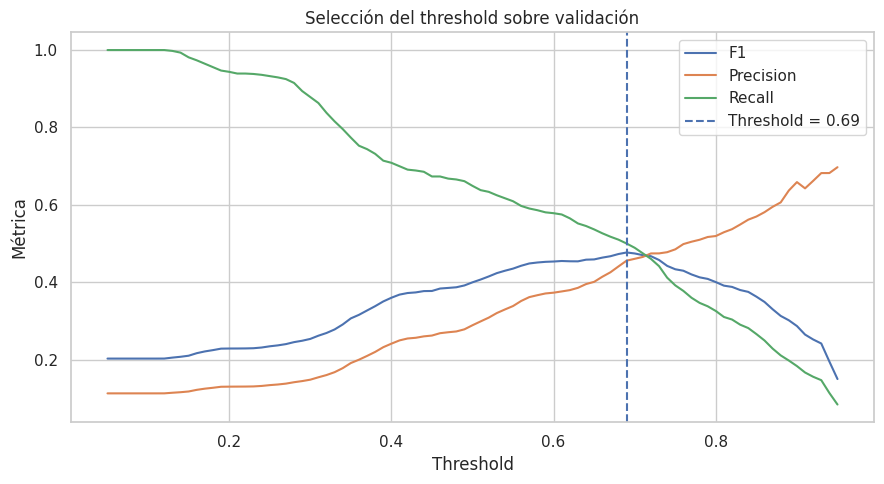

In [15]:
# Creamos una figura para visualizar el efecto del threshold.
plt.figure(figsize=(9, 5))
# Representamos F1 para cada threshold.
plt.plot(df_thresholds["threshold"], df_thresholds["f1"], label="F1")
# Representamos precision para cada threshold.
plt.plot(df_thresholds["threshold"], df_thresholds["precision"], label="Precision")
# Representamos recall para cada threshold.
plt.plot(df_thresholds["threshold"], df_thresholds["recall"], label="Recall")
# Marcamos el threshold seleccionado.
plt.axvline(best_threshold, linestyle="--", label=f"Threshold = {best_threshold:.2f}")
# Añadimos el título.
plt.title("Selección del threshold sobre validación")
# Etiquetamos el eje horizontal.
plt.xlabel("Threshold")
# Etiquetamos el eje vertical.
plt.ylabel("Métrica")
# Mostramos la leyenda.
plt.legend()
# Ajustamos los márgenes.
plt.tight_layout()
# Mostramos el gráfico.
plt.show()


## Paso 13. Evaluación final sobre el conjunto de test


In [16]:
# Calculamos las probabilidades del conjunto de test.
y_test_proba = model.predict_proba(X_test)[:, 1]
# Aplicamos al test el threshold elegido previamente en validación.
y_test_pred = (y_test_proba >= best_threshold).astype(int)
# Mostramos el informe de clasificación final.
print(classification_report(y_test, y_test_pred, digits=3))
# Calculamos el ROC-AUC final.
test_auc = roc_auc_score(y_test, y_test_proba)
# Mostramos el ROC-AUC final.
print(f"ROC-AUC test: {test_auc:.3f}")


              precision    recall  f1-score   support

           0      0.937     0.928     0.932      7132
           1      0.472     0.507     0.489       906

    accuracy                          0.881      8038
   macro avg      0.704     0.717     0.711      8038
weighted avg      0.884     0.881     0.882      8038

ROC-AUC test: 0.802


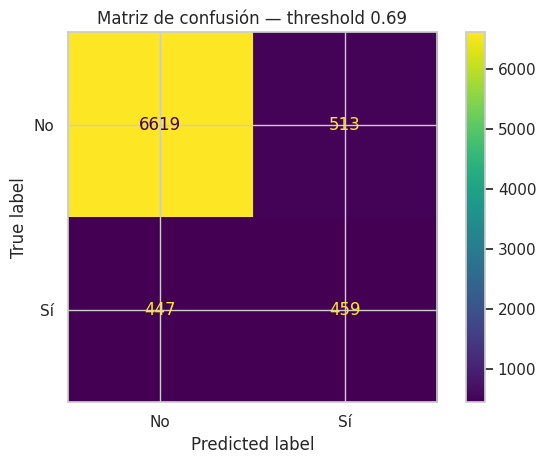

In [17]:
# Calculamos la matriz de confusión del conjunto de test.
cm = confusion_matrix(y_test, y_test_pred)
# Creamos el objeto de visualización de la matriz.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
# Dibujamos la matriz de confusión.
disp.plot()
# Añadimos el título.
plt.title(f"Matriz de confusión — threshold {best_threshold:.2f}")
# Ajustamos los márgenes.
plt.tight_layout()
# Mostramos el gráfico.
plt.show()


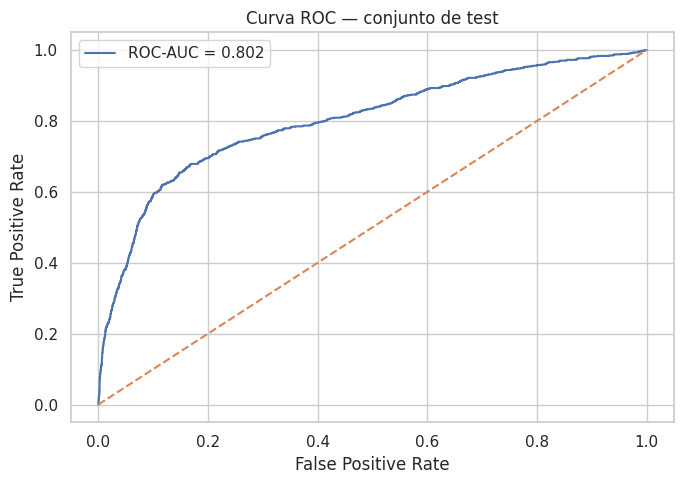

In [18]:
# Calculamos los puntos de la curva ROC.
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)
# Creamos una figura.
plt.figure(figsize=(7, 5))
# Representamos la curva ROC.
plt.plot(fpr, tpr, label=f"ROC-AUC = {test_auc:.3f}")
# Representamos la diagonal correspondiente a un clasificador aleatorio.
plt.plot([0, 1], [0, 1], linestyle="--")
# Etiquetamos el eje horizontal.
plt.xlabel("False Positive Rate")
# Etiquetamos el eje vertical.
plt.ylabel("True Positive Rate")
# Añadimos el título.
plt.title("Curva ROC — conjunto de test")
# Mostramos la leyenda.
plt.legend()
# Ajustamos los márgenes.
plt.tight_layout()
# Mostramos el gráfico.
plt.show()


## Paso 14. Interpretación de los coeficientes de la Regresión Logística


In [19]:
# Recuperamos los nombres de las variables generadas por el preprocesador.
feature_names = model.named_steps["preprocess"].get_feature_names_out()
# Recuperamos los coeficientes aprendidos por la regresión logística.
coefficients = model.named_steps["classifier"].coef_[0]
# Construimos una tabla con variable y coeficiente.
coef_table = pd.DataFrame(
    {
        # Guardamos el nombre de cada predictor transformado.
        "variable": feature_names,
        # Guardamos el coeficiente correspondiente.
        "coeficiente": coefficients
    }
)
# Calculamos el valor absoluto para ordenar por magnitud.
coef_table["magnitud"] = coef_table["coeficiente"].abs()
# Ordenamos las variables de mayor a menor magnitud.
coef_table = coef_table.sort_values("magnitud", ascending=False)
# Mostramos las variables con mayor influencia en la predicción.
display(coef_table.head(20))


,variable,coeficiente,magnitud
25,categorical__contact_month_mar,1.094829,1.094829
28,categorical__contact_month_oct,1.054819,1.054819
22,categorical__contact_month_dec,0.986762,0.986762
31,categorical__previous_campaign_outcome_success,0.868108,0.868108
35,numeric__euribor_3m_rate,-0.772617,0.772617
26,categorical__contact_month_may,-0.593692,0.593692
29,categorical__contact_month_sep,0.547670,0.547670
4,categorical__job_type_retired,0.474602,0.474602
23,categorical__contact_month_jul,0.329099,0.329099
14,categorical__education_level_illiterate,0.286989,0.286989


En una regresión logística, un coeficiente positivo aumenta el log-odds estimado de la clase positiva y uno negativo lo reduce, manteniendo constantes las demás variables. La magnitud ayuda a identificar variables influyentes, aunque la interpretación debe considerar las transformaciones y la codificación aplicada.


## Paso 15. Reentrenamiento del pipeline final

Una vez fijado el threshold mediante validación y realizada la evaluación final sobre test, se reentrena el **mismo pipeline** con todos los datos disponibles para dejar un artefacto preparado para inferencia.

El threshold se conserva por separado porque `Pipeline.predict()` utiliza 0,50 internamente; en producción utilizaremos `predict_proba()` y aplicaremos `best_threshold`.


In [20]:
# Creamos un nuevo pipeline con la misma configuración utilizada durante la evaluación.
final_model = Pipeline(
    # Definimos las mismas etapas del modelo evaluado.
    steps=[
        # Aplicamos exactamente el mismo preprocesamiento.
        ("preprocess", preprocessor),
        # Entrenamos la misma regresión logística.
        (
            "classifier",
            LogisticRegression(
                # Mantenemos la compensación del desbalance.
                class_weight="balanced",
                # Mantenemos el máximo de iteraciones.
                max_iter=1000,
                # Mantenemos la semilla.
                random_state=RANDOM_STATE
            )
        )
    ]
)

# Entrenamos el pipeline final utilizando todos los datos disponibles.
final_model.fit(X, y)
# Confirmamos que el modelo final se ha entrenado.
print("Pipeline final entrenado con todos los datos.")


Pipeline final entrenado con todos los datos.


## Paso 16. Guardado del modelo para producción


In [21]:
# Guardamos el pipeline completo en un único fichero joblib.
joblib.dump(final_model, MODEL_FILE)

# Construimos los metadatos necesarios para reproducir la inferencia.
model_metadata = {
    # Guardamos el nombre del modelo.
    "model_name": "fintech_logistic_regression",
    # Guardamos la versión inicial del modelo.
    "version": "1.0.0",
    # Guardamos el threshold elegido en validación.
    "threshold": best_threshold,
    # Guardamos el ROC-AUC obtenido en test antes del reentrenamiento final.
    "test_roc_auc": float(test_auc),
    # Guardamos las variables de entrada y su orden.
    "features": X.columns.tolist(),
    # Guardamos el mapeo de la variable objetivo.
    "target_mapping": {"no": 0, "yes": 1}
}

# Abrimos el fichero de metadatos en modo escritura.
with open(METADATA_FILE, "w", encoding="utf-8") as file:
    # Guardamos los metadatos en formato JSON legible.
    json.dump(model_metadata, file, indent=4, ensure_ascii=False)

# Mostramos la ubicación del pipeline.
print(f"Modelo guardado en: {MODEL_FILE}")
# Mostramos la ubicación de los metadatos.
print(f"Metadatos guardados en: {METADATA_FILE}")


Modelo guardado en: /home/diego/Escritorio/Fintech_TFM/03_models/logistic_regression_pipeline.joblib
Metadatos guardados en: /home/diego/Escritorio/Fintech_TFM/03_models/logistic_regression_metadata.json


## Paso 17. Comprobación del artefacto guardado


In [22]:
# Volvemos a cargar el pipeline desde disco.
loaded_model = joblib.load(MODEL_FILE)
# Seleccionamos una observación de ejemplo manteniendo formato DataFrame.
example_input = X.iloc[[0]].copy()
# Calculamos la probabilidad de suscripción de la observación.
example_probability = loaded_model.predict_proba(example_input)[:, 1][0]
# Aplicamos el threshold seleccionado.
example_prediction = int(example_probability >= best_threshold)
# Mostramos la probabilidad estimada.
print(f"Probabilidad estimada: {example_probability:.4f}")
# Mostramos la clasificación final.
print(f"Predicción: {'yes' if example_prediction == 1 else 'no'}")


Probabilidad estimada: 0.1461
Predicción: no


# Paso 18. Preparación para GitHub y producción

El fichero que debe consumir una aplicación no es solo `LogisticRegression`, sino el **pipeline completo**:

`logistic_regression_pipeline.joblib`

De esta forma, la aplicación puede enviar las variables originales y el pipeline realiza automáticamente el mismo One-Hot Encoding y escalado utilizado durante el entrenamiento.

Para un repositorio orientado a despliegue, una estructura sencilla sería:

```text
Fintech_TFM/
├── 00_data/
│   └── 01_processed/
├── 02_scripts/
├── 03_models/
│   ├── logistic_regression_pipeline.joblib
│   └── logistic_regression_metadata.json
├── notebooks/
│   └── modelo_fintech_ordenado_produccion.ipynb
├── app/
│   └── app.py
├── requirements.txt
└── README.md
```

El siguiente paso natural sería crear una pequeña API o aplicación que cargue el `.joblib`, reciba los datos de un cliente, ejecute `predict_proba()` y aplique el threshold guardado en los metadatos.
